# Exercise 17.1 solution


## Exercise 17.1a solution


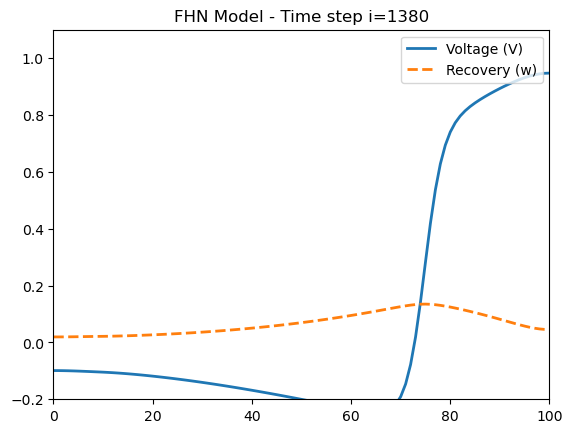

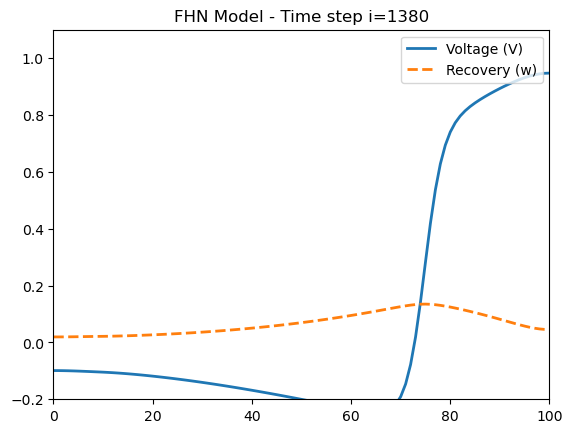

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import time

k = 2.0
A = 1.0
alpha = 0.1
L = 100
eps = 0.005
gamma = 2.0

dx = 1
dt = 0.1
N = int(L / dx)

v = np.zeros(N + 1)
w = np.zeros(N + 1)
left = int(N / 10)
v[:left] = 0.3

I = np.arange(1, N)
Ip = I + 1
Im = I - 1

for i in range(1400):
    v_prev = np.copy(v)
    w_prev = np.copy(w)

    # Calculate reaction terms
    I_ion_v = A * v_prev * (1 - v_prev) * (v_prev - alpha) - w_prev
    I_ion_w = eps * (v_prev - gamma * w_prev)

    # Add diffusion to v
    v[I] = v_prev[I] + dt * (k / dx**2) * (v_prev[Ip] - 2 * v_prev[I] + v_prev[Im])

    # Update boundary nodes for v
    v[0] = v_prev[0] + dt * (k / dx**2) * 2 * (v_prev[1] - v_prev[0])
    v[N] = v_prev[N] + dt * (k / dx**2) * 2 * (v_prev[N - 1] - v_prev[N])

    # Update state variables
    v = v + dt * I_ion_v
    w = w + dt * I_ion_w

    if i % 20 == 0:
        plt.clf()
        plt.axis([0, L, -0.2, 1.1])
        plt.plot(v, color="C0", linewidth=2, label="Voltage (V)")
        plt.plot(w, color="C1", linewidth=2, linestyle="--", label="Recovery (w)")
        plt.title(f"FHN Model - Time step i={i}")
        plt.legend(loc="upper right")
        display.clear_output(wait=True)
        display.display(plt.gcf())
        time.sleep(0.01)

## Exercise 17.1b solution


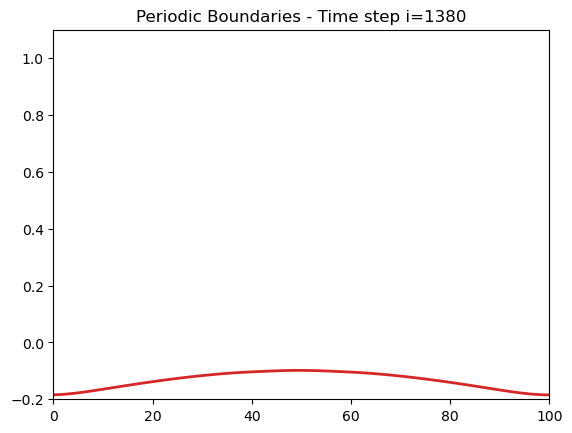

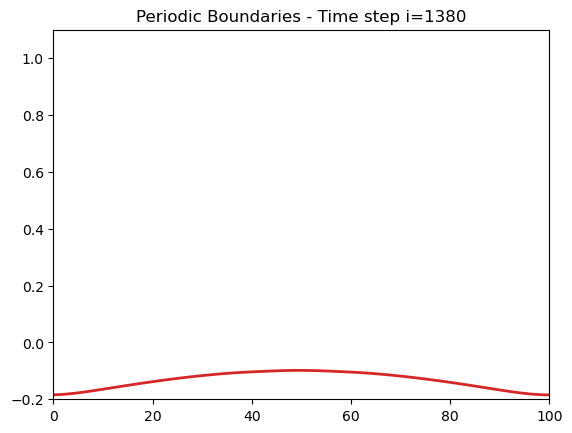

In [ ]:
v = np.zeros(N + 1)
w = np.zeros(N + 1)

mid = int(N / 2)
v[mid - 10 : mid + 10] = 0.3

I = np.arange(N + 1)
Ip = I + 1
Ip[N] = 0  # Wrap right
Im = I - 1
Im[0] = N  # Wrap left

for i in range(1400):
    v_prev = np.copy(v)
    w_prev = np.copy(w)

    I_ion_v = A * v_prev * (1 - v_prev) * (v_prev - alpha) - w_prev
    I_ion_w = eps * (v_prev - gamma * w_prev)

    # Diffusion applied to ALL nodes using wrapped slices
    v[I] = v_prev[I] + dt * (k / dx**2) * (v_prev[Ip] - 2 * v_prev[I] + v_prev[Im])

    v = v + dt * I_ion_v
    w = w + dt * I_ion_w

    if i % 20 == 0:
        plt.clf()
        plt.axis([0, L, -0.2, 1.1])
        plt.plot(v, color="C3", linewidth=2)
        plt.title(f"Periodic Boundaries - Time step i={i}")
        display.clear_output(wait=True)
        display.display(plt.gcf())
        time.sleep(0.01)

**Answer:** Because we stimulated the middle of the cable, two waves propagate outward in opposite directions. Since the cable is a continuous ring, the two waves wrap around the edges and crash into each other on the far side. Because the tissue immediately behind the wavefront is refractory (high $w$), the waves annihilate each other and completely die out.


## Exercise 17.1c solution


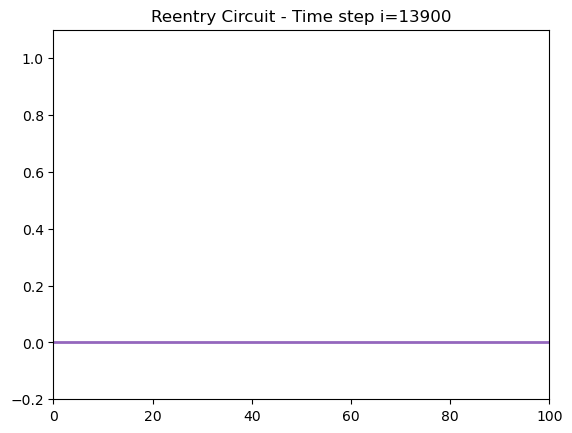

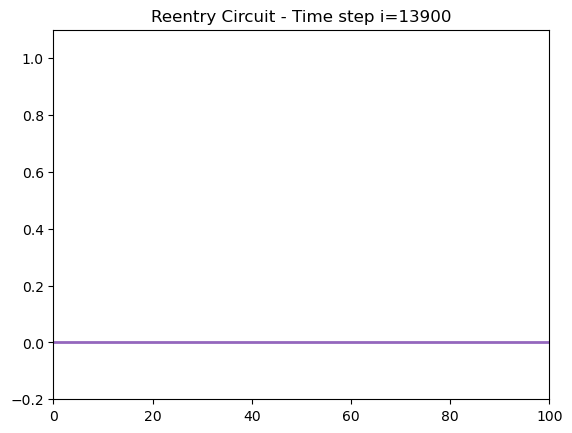

In [3]:
v = np.zeros(N + 1)
w = np.zeros(N + 1)

mid = int(N / 2)
v[mid - 10 : mid + 10] = 0.3
w[: mid - 5] = 0.2  # Artificially block the leftward wave!

I = np.arange(N + 1)
Ip = I + 1
Ip[N] = 0
Im = I - 1
Im[0] = N

# Run for 10x longer to watch the wave lap the ring!
for i in range(14000):
    v_prev = np.copy(v)
    w_prev = np.copy(w)

    I_ion_v = A * v_prev * (1 - v_prev) * (v_prev - alpha) - w_prev
    I_ion_w = eps * (v_prev - gamma * w_prev)

    v[I] = v_prev[I] + dt * (k / dx**2) * (v_prev[Ip] - 2 * v_prev[I] + v_prev[Im])

    v = v + dt * I_ion_v
    w = w + dt * I_ion_w

    if i % 100 == 0:  # Update less frequently for speed
        plt.clf()
        plt.axis([0, L, -0.2, 1.1])
        plt.plot(v, color="C4", linewidth=2)
        plt.title(f"Reentry Circuit - Time step i={i}")
        display.clear_output(wait=True)
        display.display(plt.gcf())
        time.sleep(0.01)

**Conclusion:** Because the left side of the tissue was artificially locked in a refractory state, the initial stimulus could only propagate to the right. By the time this rightward wave traveled all the way around the ring and returned to the left side, the artificial block had fully recovered.

The wave is now trapped in an endless cycle of self-sustaining activation, chasing its own tail around the physical ring of tissue! This is exactly how scarred heart tissue can trap electrical signals and trigger deadly arrhythmias.
